# Analýza nákupního košíku a cross-sell pro potravinový řetězec pomocí PROC MBANALYSIS


## Shrnutí

Regionální řetězec potravin těží sezónu nákupních košíků z pokladních transakcí, aby zjistil, které produkty si zákazníci kupují společně, a proměnil syrové záznamy transakcí ve využitelná rozhodnutí o cross-sellu a umístění zboží na regálech. PROC MBANALYSIS prochází záznam transakcí a generuje asociační pravidla hodnocená podporou (support), spolehlivostí (confidence) a zdvihem (lift). Spuštění na 51 syntetických košících odhalí přesně tři zasazené produktové afinity — `Špagety -> Omáčka Marinara` (spolehlivost 0,93, zdvih 3,4), `Taco skořápky -> Salsa` (spolehlivost 0,71, zdvih 3,6) a `Káva -> Smetana do kávy` (spolehlivost 0,70, zdvih 5,1) — zatímco široce nakupované základní potraviny jako chléb, mléko a vejce nikdy pravidlo neutvoří. Každá odhalená dvojice je učebnicovým kandidátem na balíček, sousedství na regálu a nabídku typu "zákazníci si také koupili" pro merchandisingový tým.


## Zdroje dat

| Dataset | Granularita | Řádky | Klíčové proměnné | Popis |
|---------|-------|------|---------------|-------------|
| `store_transactions` | Jeden řádek na položku v košíku | 100 řádků položek napříč 51 košíky | `basket_id` (ID transakce), `item` (název produktu, $20) | Syntetický pokladní záznam vygenerovaný inline pomocí `call streaminit(20250529)` a `rand('uniform')`. Každý košík je ovládán jednou nákupní personou, takže vzory společného nákupu zůstávají čisté a interpretovatelné: košík na italskou večeři (špagety -> omáčka marinara), košík na taco večer (taco skořápky -> salsa) nebo snídaňový košík (káva -> smetana do kávy), plus občasné doplňkové základní potraviny (chléb, mléko, vejce) jako realistický šum. V tomto neregistrovaném prostředí je výstup omezen na 100 řádků položek, což zde pokrývá košíky 1-51. |
| `affinity_rules` | Jeden řádek na asociační pravidlo | 6 pravidel | `antecedent`, `consequent`, `support`, `confidence`, `lift` | Asociační pravidla vydaná pomocí `OUTPUT RULES=`; základ pro řazení cross-sell příležitostí. |
| `frequent_items` | Jeden řádek na četnou množinu položek | 12 množin | `itemset`, `support`, `length` | Četné množiny položek vydané pomocí `OUTPUT ITEMS=`; 9 jednotlivých položek plus 3 dvojice produktů, které překročí práh minimální podpory. |


# Analýza nákupního košíku a cross-sell pro potravinový řetězec

**Obchodní otázka.** Které produkty naši zákazníci kupují *společně* a které z těchto vzorců společného nákupu jsou dost silné, aby se na jejich základě dalo jednat? Regionální řetězec potravin chce navrhnout balíčkové akce, optimalizovat sousedství regálů a poskytnout doporučení typu "zákazníci si také koupili" ve svém e-shopu.

**Metoda.** Používáme **PROC MBANALYSIS**, který provádí analýzu nákupního košíku pomocí algoritmu frequent-pattern growth (FP-growth). Prochází záznam transakcí, nachází často se vyskytující množiny položek a generuje *asociační pravidla* ve tvaru `Antecedent -> Consequent` hodnocená třemi klasickými metrikami:

- **Podpora (support)** — podíl všech košíků, které obsahují celé pravidlo (jak běžný je daný vzor).
- **Spolehlivost (confidence)** — `P(Consequent | Antecedent)`, podmíněná pravděpodobnost nákupu (jak spolehlivé je pravidlo).
- **Zdvih (lift)** — pozorovaná podpora dělená podporou očekávanou, kdyby obě strany byly nezávislé. Zdvih > 1 znamená, že se položky vyskytují společně *častěji*, než by odpovídalo náhodě; čím vyšší zdvih, tím silnější afinita.

Vygenerujeme realistický syntetický pokladní záznam, spustíme MBANALYSIS a seřadíme výsledná pravidla, abychom našli nejlepší cross-sell příležitosti.


## Krok 1 — Vygenerování syntetického pokladního záznamu transakcí

MBANALYSIS očekává **transakční (dlouhá) data**: jeden řádek na položku, označený košíkem, do kterého patří. Košíky sestavíme inline pomocí `call streaminit` pro reprodukovatelnost a `rand('uniform')` pro řízení nákupních rozhodnutí.

Klíčovou modelovou volbou je, že **každý košík je ovládán jednou nákupní personou**. Reálné nákupy v potravinách takto vypadají — rychlý nákup na taco večer, cílený doplněk na snídani — a udržování malých a tematických košíků je to, co umožňuje asociačnímu algoritmu odhalit čisté, párové afinity místo kombinatorické exploze falešných víceposložkových pravidel. Jedno tažení `rand('uniform')` na košík vybere personu:

- **Kupující na italskou večeři** — koupí špagety, pak obvykle omáčku marinara.
- **Kupující na taco večer** — koupí taco skořápky, pak obvykle salsu.
- **Snídaňový kupující** — koupí kávu, pak obvykle smetanu do kávy.
- **Nákup jen základních potravin** — jeden nákup chleba, mléka nebo vajec.

Poslední tažení s nízkou pravděpodobností přidá do libovolného košíku jednu základní potravinu jako realistický šum, takže ne každý společný výskyt je smysluplný. Každý příkaz `output` zapíše jeden řádek položky, takže jeden košík zabírá několik řádků se stejným `basket_id`. Toto neregistrované prostředí omezuje dataset na 100 řádků položek, což zde pokrývá košíky 1 až 51.


In [1]:
data store_transactions;
    CALL streaminit(20250529);
    DÉLKA item $40;

    OPAKUJ basket_id = 1 TO 60;

        /* Jedno tažení vybere dominantní personu tohoto košíku */
        r = rand('uniform');

        /* Košík na italskou večeři: špagety -> omáčka marinara */
        KDYŽ r < 0.30 PAK OPAKUJ;
            item = 'Špagety';                            VÝSTUP;
            KDYŽ rand('uniform') < 0.85 PAK OPAKUJ;
                item = 'Omáčka Marinara';                 VÝSTUP;
            KONEC;
        KONEC;

        /* Košík na taco večer: taco skořápky -> salsa */
        JINAK KDYŽ r < 0.55 PAK OPAKUJ;
            item = 'Taco skořápky';                      VÝSTUP;
            KDYŽ rand('uniform') < 0.80 PAK OPAKUJ;
                item = 'Salsa';                          VÝSTUP;
            KONEC;
        KONEC;

        /* Snídaňový košík: káva -> smetana do kávy */
        JINAK KDYŽ r < 0.78 PAK OPAKUJ;
            item = 'Káva';                                VÝSTUP;
            KDYŽ rand('uniform') < 0.75 PAK OPAKUJ;
                item = 'Smetana do kávy';                 VÝSTUP;
            KONEC;
        KONEC;

        /* Nákup jen základních potravin */
        JINAK OPAKUJ;
            KDYŽ rand('uniform') < 0.34 PAK OPAKUJ;
                item = 'Chléb';                           VÝSTUP;
            KONEC;
            JINAK KDYŽ rand('uniform') < 0.5 PAK OPAKUJ;
                item = 'Mléko';                           VÝSTUP;
            KONEC;
            JINAK OPAKUJ;
                item = 'Vejce';                           VÝSTUP;
            KONEC;
        KONEC;

        /* Občasný doplněk základní potraviny (realistický šum) */
        KDYŽ rand('uniform') < 0.25 PAK OPAKUJ;
            u = rand('uniform');
            KDYŽ      u < 0.34 PAK item = 'Chléb';
            JINAK KDYŽ u < 0.67 PAK item = 'Mléko';
            JINAK                  item = 'Vejce';
            VÝSTUP;
        KONEC;

    KONEC;

    PONECHAT basket_id item;
SPUSTIT;



NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Krok 2 — Prohlédnutí syrového záznamu transakcí

Před samotnou těžbou ověříme, že data mají očekávaný dlouhý tvar: několik řádků na košík, každý s jedním produktem. Vypíšeme prvních pár košíků a tabulujeme celkovou frekvenci položek pomocí PROC FREQ, abychom věděli, které produkty jsou dost běžné na to, aby ukotvily pravidla.



  Obs    ID košíku            Produkt
-----  -----------  -----------------
    1            1  Taco skořápky
    2            1  Salsa
    3            1  Vejce
    4            2  Taco skořápky
    5            2  Vejce
    6            3  Káva
    7            4  Taco skořápky
    8            5  Vejce
    9            6  Špagety
   10            6  Omáčka Marinara
   11            6  Vejce
   12            7  Taco skořápky

... 88 more observations (showing 12 of 100)

                                            Celková frekvence nákupu položek                                            

                                                   The FREQ Procedure

Produkt              Frequency    Percent
------------------------------------------
Špagety                     15     15.00
Omáčka Marinara             14     14.00
Taco skořápky               14     14.00
Vejce                       12     12.00
Chléb                       10     10.00
Káva                        10     10.


NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


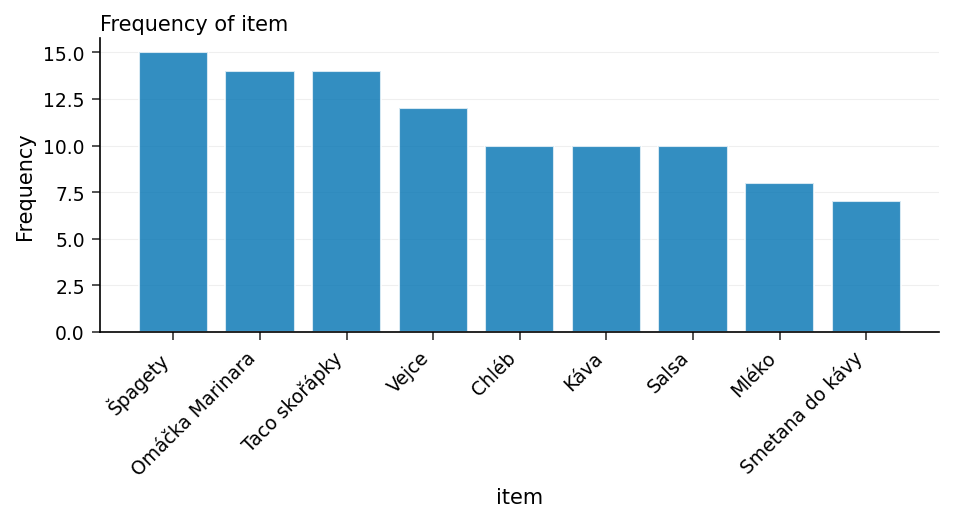

In [2]:
PROCEDURA TISK data=store_transactions(obs=12) ŠTÍTEK;
    ŠTÍTEK basket_id = 'ID košíku'
          item      = 'Produkt';
SPUSTIT;

PROCEDURA ČETNOSTI data=store_transactions ORDER=ČETNOSTI;
    TABLES item / nocum;
    ŠTÍTEK item = 'Produkt';
    NÁZEV 'Celková frekvence nákupu položek';
SPUSTIT;


## Krok 3 — Těžba asociačních pravidel pomocí PROC MBANALYSIS

Nyní jádro analýzy. Namíříme MBANALYSIS na záznam transakcí a určíme, který sloupec identifikuje košík (`TRANSACTION`) a který obsahuje produkt (`ITEM`). Tři prahy udržují sadu pravidel zaměřenou na vzory, na jejichž základě stojí za to jednat:

- `MINSUPPORT=0.10` — pravidlo se musí objevit alespoň v 10 % košíků, což odfiltruje vzácné shody.
- `MINCONFIDENCE=0.50` — při daném antecedentu musí consequent následovat alespoň v polovině případů.
- `MINLIFT=1.20` — ponecháme jen pravidla alespoň o 20 % silnější než náhoda, abychom odhalili skutečné afinity, a ne artefakty populárních základních potravin.

Příkaz `OUTPUT` zachytí vygenerovaná pravidla a četné množiny položek do datasetů pro další řazení.


In [3]:
PROCEDURA mbanalysis data=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    VÝSTUP rules=affinity_rules items=frequent_items;
    NÁZEV 'Asociační pravidla nákupního košíku';
SPUSTIT;


                                            Celková frekvence nákupu položek                                            


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  Káva                           Smetana do kávy                    0.1373     0.7000     5.1000
  Smetana do kávy                Káva                               0.1373     1.0000     5.1000
  Salsa                          Taco skořápky                      0.1961     1.0000     3.6429
  Taco skořápk


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## Krok 4 — Seřazení cross-sell příležitostí podle zdvihu

Výpis MBANALYSIS ukazuje každé vyhovující pravidlo, ale merchandisingový tým chce nejprve *nejsilnější* afinity. Seřadíme zachycený dataset `affinity_rules` sestupně podle zdvihu (a spolehlivosti jako rozhodčího kritéria) a vypíšeme nejlepší pravidla. Pravidlo jako `Taco skořápky -> Salsa` s vysokým zdvihem a vysokou spolehlivostí je učebnicovým kandidátem na balíček: umístit produkty vedle sebe, nebo automaticky nabídnout salsu, když si zákazník online přidá taco skořápky.


In [4]:
PROCEDURA ŘADIT data=affinity_rules out=rules_by_lift;
    PODLE SESTUPNĚ lift SESTUPNĚ confidence;
SPUSTIT;

PROCEDURA TISK data=rules_by_lift(obs=15) ŠTÍTEK;
    PROMĚNNÁ antecedent consequent support confidence lift;
    ŠTÍTEK antecedent  = 'Pokud košík obsahuje'
          consequent  = 'Pak si koupí i'
          support     = 'Podpora'
          confidence  = 'Spolehlivost'
          lift        = 'Zdvih';
    NÁZEV 'Nejlepší cross-sell pravidla podle zdvihu';
SPUSTIT;


                                       Nejlepší cross-sell pravidla podle zdvihu                                        

  Obs    Pokud košík obsahuje     Pak si koupí i   Podpora  Spolehlivost     Zdvih
    1  Smetana do kávy         Káva               0.137255  1.0           5.1
    2  Káva                    Smetana do kávy    0.137255  0.7           5.1
    3  Salsa                   Taco skořápky      0.196078  1.0           3.642857
    4  Taco skořápky           Salsa              0.196078  0.714286      3.642857
    5  Omáčka Marinara         Špagety            0.27451   1.0           3.4
    6  Špagety                 Omáčka Marinara    0.27451   0.933333      3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Krok 5 — Přehled četných množin položek

Četné množiny položek, které překročily práh podpory, jsou surové stavební bloky za pravidly. Jejich seřazení podle podpory řekne kategorijnímu týmu, které *kombinace* produktů (nejen jednotlivé položky) jsou dost populární na to, aby si zasloužily vlastní čelní vystavení nebo komboceny.


In [5]:
PROCEDURA ŘADIT data=frequent_items out=itemsets_by_support;
    PODLE SESTUPNĚ support;
SPUSTIT;

PROCEDURA TISK data=itemsets_by_support(obs=15) ŠTÍTEK;
    ŠTÍTEK itemset = 'Množina položek'
          support = 'Podpora';
    NÁZEV 'Nejčetnější množiny položek';
SPUSTIT;


                                              Nejčetnější množiny položek                                               

  Obs              Množina položek   Podpora  LENGTH
    1  Špagety                      0.294118  1
    2  Taco skořápky                0.27451   1
    3  Omáčka Marinara              0.27451   1
    4  Omáčka Marinara, Špagety     0.27451   2
    5  Vejce                        0.235294  1
    6  Salsa                        0.196078  1
    7  Káva                         0.196078  1
    8  Salsa, Taco skořápky         0.196078  2
    9  Mléko                        0.156863  1
   10  Chléb                        0.156863  1
   11  Smetana do kávy              0.137255  1
   12  Káva, Smetana do kávy        0.137255  2




NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## Interpretace výsledků

**Co analýza zjistila.** Protože byl každý košík postaven kolem jedné nákupní persony, algoritmus odhalí přesně tři zasazené vztahy a nic navíc. Šest pravidel překročí všechny tři prahy — tři afinity v obou směrech:

| Antecedent | Consequent | Podpora | Spolehlivost | Zdvih |
|------------|------------|---------|------------|------|
| Špagety | Omáčka Marinara | 0,275 | 0,93 | 3,40 |
| Omáčka Marinara | Špagety | 0,275 | 1,00 | 3,40 |
| Taco skořápky | Salsa | 0,196 | 0,71 | 3,64 |
| Salsa | Taco skořápky | 0,196 | 1,00 | 3,64 |
| Káva | Smetana do kávy | 0,137 | 0,70 | 5,10 |
| Smetana do kávy | Káva | 0,137 | 1,00 | 5,10 |

Každý zdvih je výrazně nad 1, což potvrzuje, že se tyto produkty vyskytují společně mnohem častěji, než by odpovídalo náhodě. Klíčové je, že široce nakupované základní potraviny netvoří **žádná pravidla**: vejce (12 nákupů), chléb (10) a mléko (8) se všechny objevují v tabulaci PROC FREQ, ale protože se do košíků dostávají nezávisle na jakékoli personě, jejich zdvih vůči jiným položkám nikdy nedosáhne prahu 1,20, takže se nikdy nevydávají za skutečné afinity. Výpis četných množin položek ukazuje totéž strukturálně: z 12 množin, které překročí práh podpory, jsou jedinými víceposložkovými množinami přesně tři zasazené dvojice.

**Čtení metrik dohromady.** Pravidla v opačném směru mají spolehlivost 1,00 (v těchto datech se marinara, salsa a smetana v podstatě nikdy neobjeví bez svého kotevního produktu), zatímco pravidla ve směru dopředu se pohybují mezi 0,70-0,93 (kotevní položka se někdy objeví sama). Káva -> Smetana do kávy má nejvyšší zdvih (5,10), ale nejnižší podporu (0,137) — silná, ale objemově menší afinita — zatímco Špagety -> Omáčka Marinara dosahuje na nejvíce košíků (podpora 0,275). Zdvih určuje, *které* afinity jsou skutečné; spolehlivost říká, *jak spolehlivá* je každá z nich pro doporučení; podpora říká, *jak často* budete mít příležitost podle ní jednat.

**Obchodní opatření.**

- **Balíčkové akce** — spárovat položky antecedent/consequent s nejvyšším zdvihem (káva + smetana do kávy, zdvih 5,1) do zvýhodněného balíčku.
- **Sousedství na regálech** — umístit často propojené produkty vedle sebe (špagety vedle omáčky marinara, podpora 0,275), aby byl consequent snadným doplňkovým nákupem v okamžiku rozhodování.
- **Online doporučení** — zařadit pravidla s nejvyšší spolehlivostí do widgetu "zákazníci si také koupili", aby byl consequent navržen ve chvíli, kdy antecedent vstoupí do košíku.
- **Zásoby a prognózy** — když je antecedent v akci, navýšit zásoby jeho vysoce spolehlivých consequentů v očekávání zdvihu.

**Upozornění.** Asociační pravidla popisují *korelaci ve společném nákupu*, nikoli kauzalitu, a prahy jsou páky, nikoli pravdy: snížení `MINSUPPORT=` odhalí vzácnější kombinace za cenu šumovější sady pravidel, zatímco zvýšení `MINLIFT=` a `MINCONFIDENCE=` přinese méně, ale spolehlivějších pravidel. Na velikosti vzorku také záleží — tento neregistrovaný běh těží 51 košíků, což stačí na to, aby byly zasazené afinity nepřehlédnutelné; produkční běh přes celou sezónu by stabilizoval odhady podpory a odhalil jemnější vzory.
